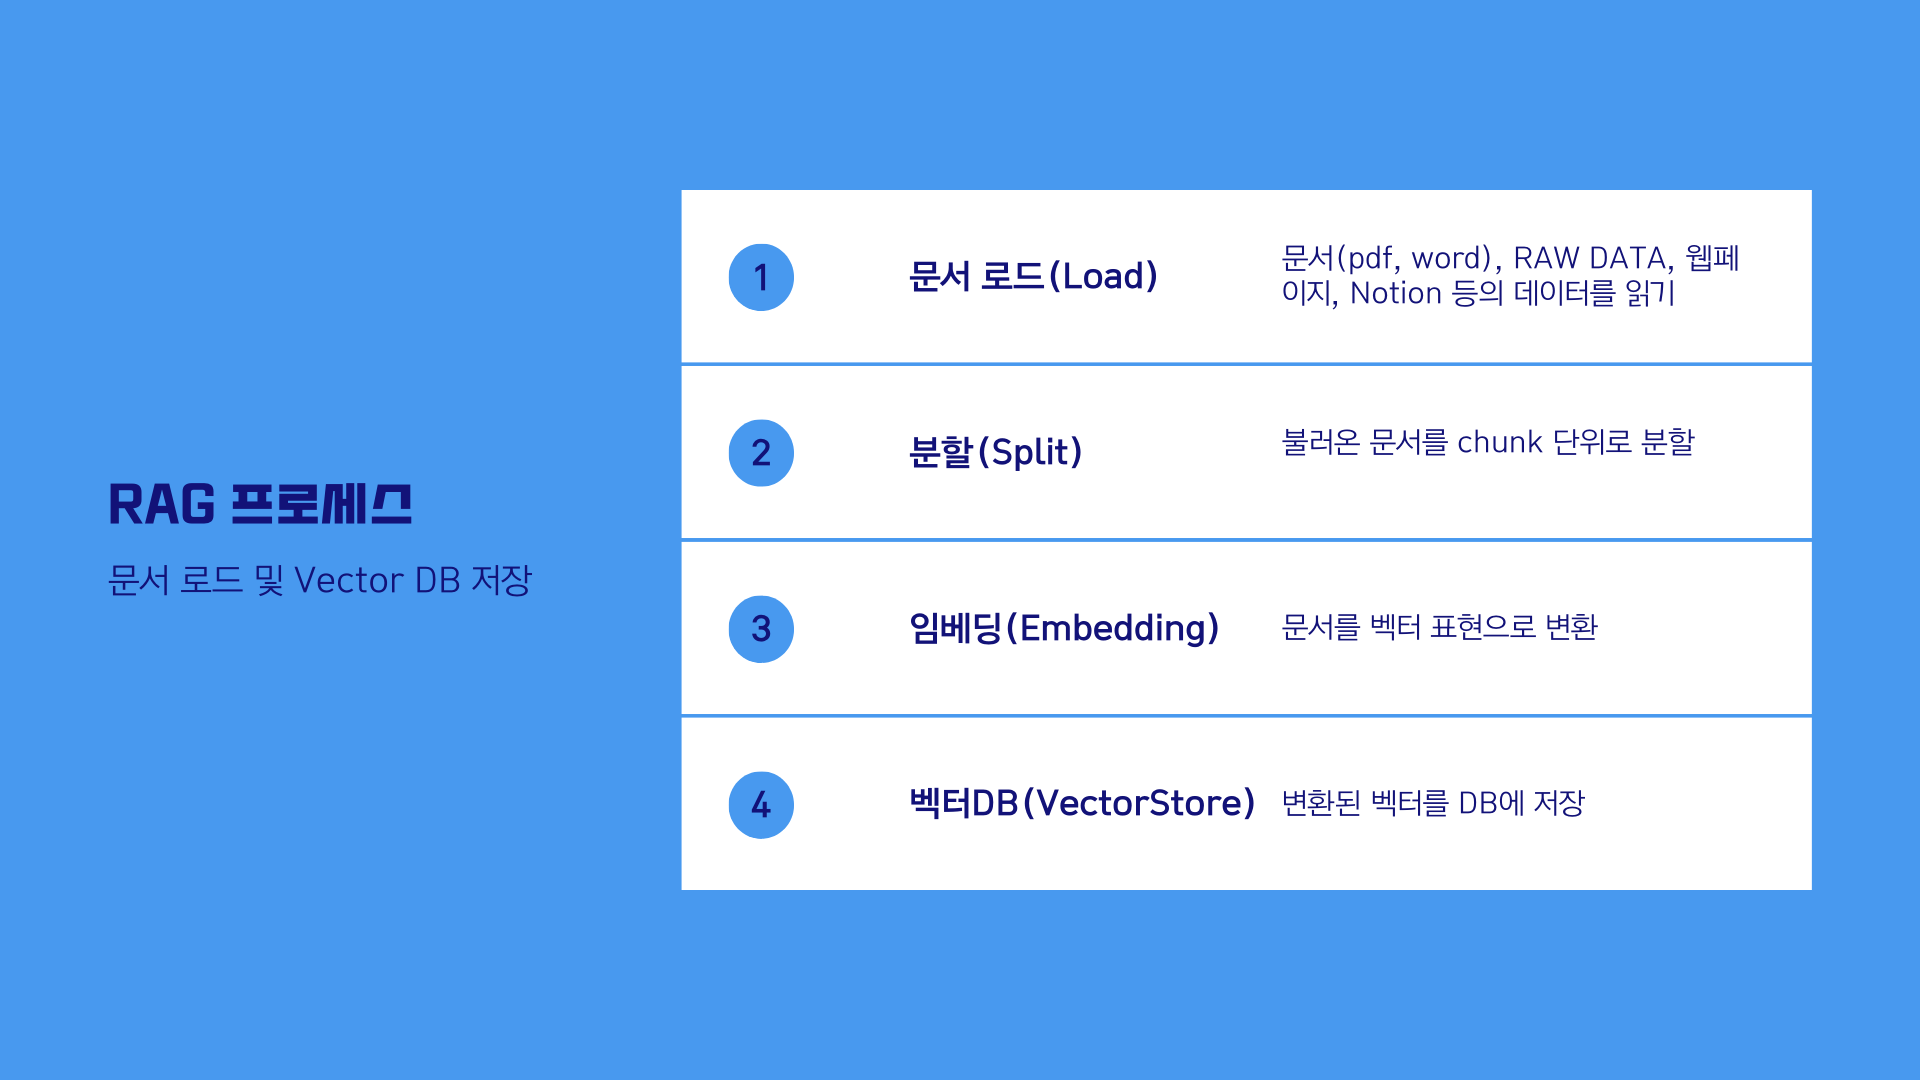

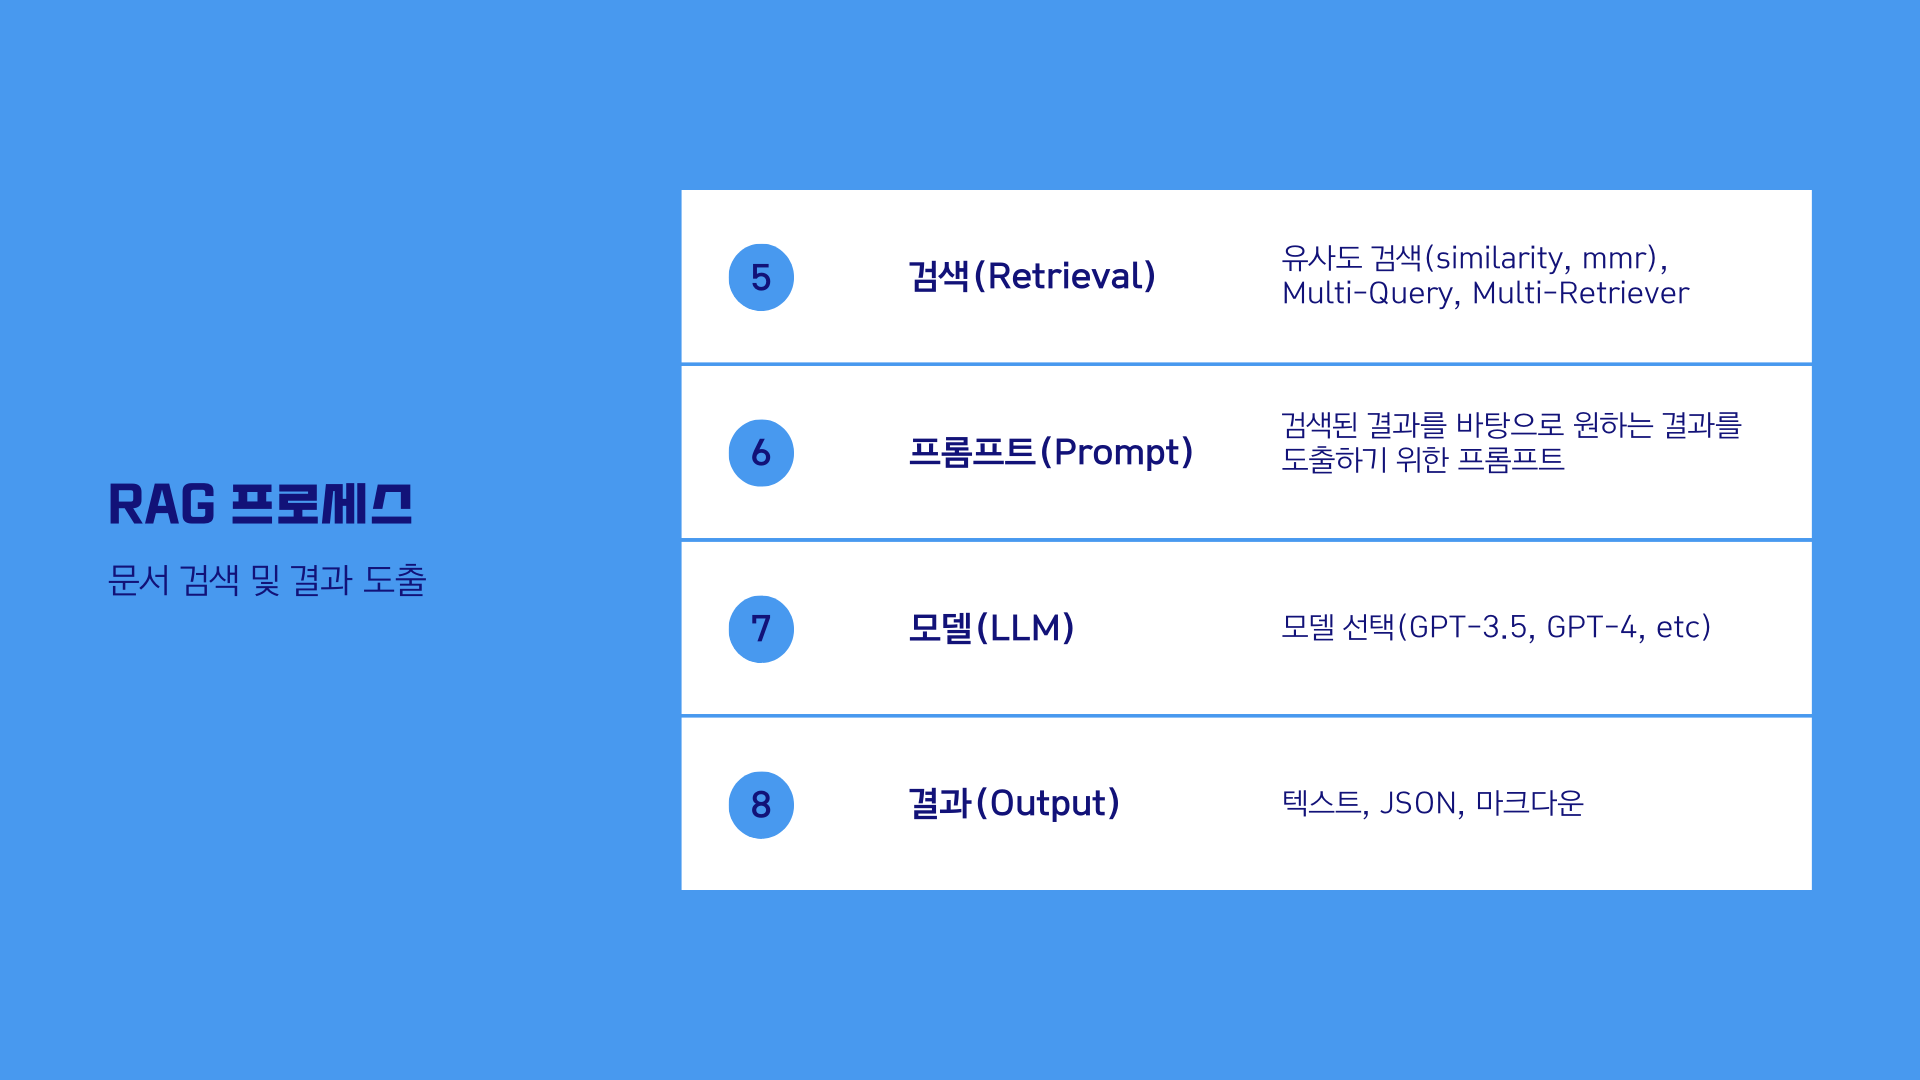

필요 라이브러리 다운로드

사용할 PDF 파일 다운로드

In [21]:
!pip install pypdf faiss-cpu
!pip install gdown
!pip install langchain langchain-huggingface langchain-community
!pip install transformers==4.47.0
!pip install datasets==2.20.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


필요 라이브러리 불러오기

In [22]:
# import gdown
# # 파일 ID로 파일 다운로드
# file_id = "1AsXa-Lk3Xl9Wbz5cm7Av-7JuOekJWs5r"
# gdown.download(f"https://drive.google.com/uc?id={file_id}", "1582771654_52314.pdf", quiet=False)

In [23]:
# 필요한 모듈 임포트
from langchain.document_loaders import PyPDFLoader  # PDF 문서를 불러오는 도구
from langchain.llms import HuggingFaceHub           # Hugging Face에서 언어 모델을 불러오는 도구
from langchain.text_splitter import RecursiveCharacterTextSplitter  # 문서를 여러 조각으로 분할하는 도구
from langchain.vectorstores import FAISS            # 벡터스토어를 생성하는 도구 (문서 검색용)
from langchain.embeddings import HuggingFaceEmbeddings   # 문서를 벡터화할 때 사용하는 임베딩 도구
from langchain.prompts import PromptTemplate        # AI 모델이 사용할 질문 템플릿 생성 도구
from langchain.chains import LLMChain               # 언어 모델과 질문을 연결해 답변을 생성하는 도구
from langchain.retrievers import BM25Retriever, EnsembleRetriever
# from sentence_transformers import SentenceTransformer  # SentenceTransformer 클래스 임포트
# from google.colab import userdata
import os
import re

허깅페이스 토큰 불러오기 및 환경변수 설정

In [24]:
# HUGGINGFACEHUB_API_TOKEN 환경 변수를 설정합니다.
os.environ["HUGGINGFACEHUB_API_TOKEN"] = 'token'

PDF 파일 불러오기 및 청크로 분할

In [25]:
# PDF 파일 경로를 설정하여 파일을 로드
file_path = "./ERA5.pdf"  # 분석할 PDF 파일 경로
loader = PyPDFLoader(file_path=file_path)    # 파일 로더를 사용해 PDF 파일을 불러옴

# 문서를 작은 청크(덩어리)로 분할
# text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=50)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=30)
split_docs = loader.load_and_split(text_splitter=text_splitter)  # PDF를 청크로 나누어 저장

# 특수 문자와 줄바꿈 제거 함수 정의
def clean_text(text):
    # 특수문자와 줄바꿈(\n) 제거
    cleaned_text = re.sub(r'[^A-Za-z0-9가-힣\s]', '', text)  # 영어, 숫자, 한글, 공백만 남기기
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)  # 연속된 공백을 하나로 축소
    return cleaned_text.strip()

# split_docs의 각 page_content에 대해 클린 텍스트 생성
for doc in split_docs:
    doc.page_content = clean_text(doc.page_content)

In [26]:
split_docs

[Document(page_content='Received 3 September 2019 Revised 17 March 2020 Accepted 30 March 2020 Publishedon 15 June 2020', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='DOI101002qj3803 RESEARCH ARTICLE The ERA5 global reanalysis', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='HansHersbach1 BillBell1 PaulBerrisford1 ShojiHirahara2 AndrsHornyi1 Joaqun', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='MuozSabater1 JulienNicolas1 CarolePeubey1 RalucaRadu1 Dinand', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='Schepers1 AdrianSimmons1 CornelSoci1 SalehAbdalla1 Xavier', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='Abellan1 GianpaoloBalsamo1 PeterBechtold1 GionataBiavati1 Jean', metadata={'source': './ERA5.pdf', 'page': 0}),
 Document(page_content='Bidlot1 MassimoBonavita1 GiovannaDeChiara 1 PerDahlgren3 DickDee1 Michail', metadata={'source': './ERA5.pdf', 'page': 0}),
 D

벡터스토어 생성
- 다양한 모델 선택 가능

In [32]:
# 벡터스토어 생성
model_name = 'sentence-transformers/all-MiniLM-L6-v2' #'snunlp/KR-SBERT-V40K-klueNLI-augSTS' 등 다양한 모델 직접 입력하여 비교가능
embedding = HuggingFaceEmbeddings(model_name=model_name)

vectorstore = FAISS.from_documents(documents=split_docs, embedding=embedding)

리트리버 생성
- 다양한 모델 선택 가능

In [33]:
# 리트리버 생성
k = 10  # 검색할 관련 문서 개수를 10개로 설정
faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": k})  # 벡터스토어에서 검색 기능 생성

 AI 모델이 사용할 프롬프트 템플릿 설정

In [34]:
from langchain_huggingface import HuggingFaceEndpoint
from langchain.prompts import PromptTemplate

# AI 모델이 사용할 프롬프트 템플릿 설정
prompt_template = PromptTemplate(
    input_variables=["context", "question"],  # 입력값으로 'context'와 'question' 사용
    # template="Given the context: {context}\nAnswer the question: {question}"
    template="주어진 텍스트: {context}\n주어진 텍스트를 다듬어줘: {question}"
)

문서 결과를 포맷하는 함수 정의 및 문서 검색

In [42]:
# 검색된 문서 결과를 포맷하는 함수 정의
def format_docs(docs):
    # 검색된 각 문서의 텍스트를 결합하여 하나의 문자열로 반환
    return "\n\n".join(doc.page_content for doc in docs)

# 질문을 설정하고 문서를 검색
question = "how collect satellite data"
retrieved_docs = faiss_retriever.get_relevant_documents(question)  # 질문에 맞는 문서 검색
formatted_context = format_docs(retrieved_docs)  # 검색된 문서를 하나의 문자열로 포맷

In [44]:
formatted_context

'satellite datasets which were acquired from a number of\n\nsitive data predominantly from the TOVS satellites and\n\nkey datasets have been improved for the early satellite\n\nrection for satellite data in a numerical weather prediction sys\n\nysis regarding satellite data rescue has been initiated as\n\nand processing of conventional and satellite measure\n\ndatasets such as radiosondes or satellite retrievals is not\n\nthe observation operator for a number of satellite chan\n\nedition 3 Technical Report Satellite Application Facility on\n\nCHAMP ChallengingMiniSatellitePayload CIMSS Cooperative Institute for Meteorological Satellite'

결과출력 및 확인

RAG 사용

In [39]:
from langchain import PromptTemplate
from langchain.llms import OpenAI
api_key = 'token'
llm = OpenAI(openai_api_key=api_key)

#질문과 검색된 문서를 연결해 답변 생성하는 체인 설정
chain = LLMChain(
    llm = OpenAI(openai_api_key=api_key),  # Hugging Face에서 불러온 언어 모델
    prompt=prompt_template,  # 위에서 정의한 프롬프트 템플릿
)

In [ ]:
# 질문에 대한 답변 생성
response = chain.invoke({"context": formatted_context, "question": question})

# 결과 출력
print(f"PDF Path: {file_path}")  # PDF 파일 경로 출력
print(f"문서의 수: {len(split_docs)}")  # PDF에서 분할된 청크(문서)의 수 출력
print("===" * 20)
print(f"[HUMAN]\n{question}")  # 사용자의 질문 출력
print(f"[AI]\n{response}")  # AI가 생성한 답변 출력

RAG 미사용

In [ ]:
# 질의내용
question = "how collect satellite data"

# 템플릿
template = """Question: {question}

Answer: """

# 프롬프트 템플릿 생성
prompt = PromptTemplate(template=template, input_variables=["question"])

#질문과 검색된 문서를 연결해 답변 생성하는 체인 설정
chain = LLMChain(prompt=prompt, llm=OpenAI(openai_api_key=api_key))

# 질문에 대한 답변 생성
print(chain.invoke(input=question))

RAG 사용 시, 원하는 도메인 관련 답변을 생성하는 것을 확인할 수 있음

# Airpod PDF RAG 실습

In [ ]:
# 문서를 작은 청크(덩어리)로 분할
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=30)
split_docs = loader.load_and_split(text_splitter=text_splitter)  # PDF를 청크로 나누어 저장

# 특수 문자와 줄바꿈 제거 함수 정의
def clean_text(text):
    # 특수문자와 줄바꿈(\n) 제거
    cleaned_text = re.sub(r'[^A-Za-z0-9가-힣\s]', '', text)  # 영어, 숫자, 한글, 공백만 남기기
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)  # 연속된 공백을 하나로 축소
    return cleaned_text.strip()

# split_docs의 각 page_content에 대해 클린 텍스트 생성
for doc in split_docs:
    doc.page_content = clean_text(doc.page_content)

In [15]:
# PDF 파일 경로를 설정하여 파일을 로드
file_id = "1kaRNMu0SLbQiY3L6qFxQzW6yD62S7pNp"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "airpod_.pdf", quiet=False)

file_path = "airpod_.pdf"  # 분석할 PDF 파일 경로
loader = PyPDFLoader(file_path=file_path)    # 파일 로더를 사용해 PDF 파일을 불러옴

Downloading...
From: https://drive.google.com/uc?id=1kaRNMu0SLbQiY3L6qFxQzW6yD62S7pNp
To: /content/airpod_.pdf
100%|██████████| 739k/739k [00:00<00:00, 75.4MB/s]


In [45]:
# 벡터스토어 생성
model_name = "sentence-transformers/all-MiniLM-L6-v2"  # 영어 PDF 사용 시
# model_name = 'snunlp/KR-SBERT-V40K-klueNLI-augSTS' # 한글 PDF 사용 시
embedding = HuggingFaceEmbeddings(model_name=model_name)

vectorstore = FAISS.from_documents(documents=split_docs, embedding=embedding)

In [46]:
# 리트리버 생성
k = 10  # 검색할 관련 문서 개수를 10개로 설정
faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": k})  # 벡터스토어에서 검색 기능 생성

In [ ]:
# 검색된 문서 결과를 포맷하는 함수 정의
def format_docs(docs):
    # 검색된 각 문서의 텍스트를 결합하여 하나의 문자열로 반환
    return "\n\n".join(doc.page_content for doc in docs)

# 질문을 설정하고 문서를 검색
# question = "If there is a problem with the battery"
question = "how collect satellite data"
retrieved_docs = faiss_retriever.get_relevant_documents(question)  # 질문에 맞는 문서 검색
formatted_context = format_docs(retrieved_docs)  # 검색된 문서를 하나의 문자열로 포맷

In [53]:
formatted_context

'increased number of levels in the vertical relative to ear\n\nacknowledged Preparation of ERA5 has been supported\n\nearupdatesatfullresolutioninouterloopstrajectories\n\nERA5 was produced with funding from this Service The\n\nas instruments and channels gradually fail ERA5 uses\n\nMERRA2 and JRA55 Section 10 summarizes strengths and weaknesses of ERA5 and ends with concluding\n\nERA5 is given in Section 4 Section 5 details the obser\n\nBased on experience of the production of ERA5 so far it\n\nERA5Cy41r2manysignificantimprovementshavebeen\n\nERA5reanalysisasapotentialreferencedatasetforhydrological'

In [ ]:
from langchain import PromptTemplate, LLMChain
from langchain.llms import OpenAI

api_key = 'token'

llm = OpenAI(openai_api_key=api_key)

prompt_template = PromptTemplate(
    input_variables=["context", "question"],  # 입력값으로 'context'와 'question' 사용
    # template="Given the context: {context}\nAnswer the question: {question}"
    template='''
                '관련 자료'를 바탕으로 'question'에 적합한 답변을 한국어로 생성하시오.
                question: {question}
                관련자료: {context}\n
                '''
)
# LLM 체인 설정
chain = LLMChain(
    llm=llm,
    prompt=prompt_template
)

# 질문에 대한 답변 생성
response = chain.invoke({"context": formatted_context, "question": question})

# 결과 출력
print(f"PDF Path: {file_path}")
print(f"문서의 수: {len(split_docs)}")
print("===" * 20)
print(f"[HUMAN]\n{question}\n{formatted_context}")
print(f"[AI]\n{response['text']}")


PDF Path: airpod_.pdf
문서의 수: 239
[HUMAN]
I phone troubleshooting
사용자 매뉴얼 User Manual

합니다 살균공정을 제대로 실시하지 않으면 설비는 제조공정으로 진입하지 않습니다 살균공정이 완료되면 설비는 자동적으로 보존공정으로 넘어갑니다

이어야 합니다 관리자가 설비를 쉽게 감독할 수 있는 장소여야 합니다 설치작업은 해당국가의 제반 법 규정에 맞게 진행되어야 합니다

대한 청소만 실시합니다 청소알림 표시가 있는 경우에는 설비 를 완전히 분해하여 세척 및 소독작 업을 진행해야 합니다 1 2 1 2

U01 시간Hours 날짜 및 시간 설정 U02 분Minutes U03 요일Day of Week U04 일자Day of Month

바랍니다

현장에 준비된 전원은 설비의 명판에 표시된 내용과 일치해야 합니다 테이블의 바닥 면은 평평하고 단단하며 하중을 충분히 견딜 수 있어야 합니다

함께 진행해야 합니다 3 설비의 이동 경로를 정할 때 가능한 울퉁불퉁한 길은 피하시고 통로의 폭 및 돌출 된 부분은 없는지 등을 사전에 확인합니다

리나 혹은 부품에 대한 교체비용은 고객이 부담해야 합니다 33 설치 후 작업내용 설비를 작동시키기 전에 먼저 아래의 내용을 실시합니다

을 갖추고 있으며 해당 법규에 맞게 작업을 진행할 수 있는 전문 기술자에 의해 수 행되어야 합니다 설비가 설치되는 장소는 아래의 내용을 충족해야 합니다
[AI]

아이폰 문제 해결 방법은 사용자 매뉴얼을 참고하는 것입니다. 살균 공정을 정확히 실시하지 않으면 설비는 제조 공정으로 넘어가지 못합니다. 살균이 완료되면 설비는 자동으로 보존 공정으로 진행됩니다. 이를 위해서는 관리자가 설비를 쉽게 감독할 수 있는 장소여야 합니다. 설치 작업은 해당 국가의 법규에 맞게 진행되어야 합니다.

설비를 청소할 때는 대한 청소만 실시해야 합니다. 청소 알림 표시가 있는 경우에는 설비를 완전히 분해하여 세척 및 소독 작업을 진행해야 합니다. 시간, 분, 요일, 일자 등